In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset from CSV
file_path = "Breast_Cancer.csv"  # Change to your actual CSV file path
df = pd.read_csv(file_path)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Convert categorical columns to numerical using Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Encode categorical data
    label_encoders[col] = le  # Store encoder if needed for inverse transformation

# Separate features and target
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Determine maximum LDA components allowed
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
n_components = min(n_features, n_classes - 1)

# Apply LDA with corrected n_components
lda = LDA(n_components=n_components)
X_lda = lda.fit_transform(X_train, y_train)

# Plot the LDA results if n_components >= 2
if n_components >= 2:
    plt.figure(figsize=(8, 6))
    for class_label in np.unique(y_train):
        plt.scatter(X_lda[y_train == class_label, 0], X_lda[y_train == class_label, 1], label=f"Class {class_label}")

    plt.xlabel("LDA Component 1")
    plt.ylabel("LDA Component 2")
    plt.title("LDA Projection")
    plt.legend()
    plt.grid()
    plt.show()
else:
    print("LDA reduced to a single component, cannot plot a 2D graph.")


LDA reduced to a single component, cannot plot a 2D graph.


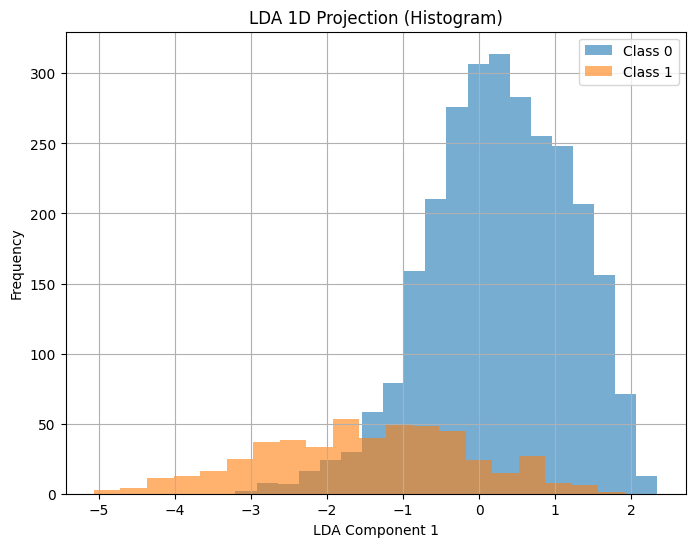

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load dataset from CSV
file_path = "Breast_Cancer.csv"  # Change to your actual CSV file path
df = pd.read_csv(file_path)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Convert categorical columns to numerical using Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  # Encode categorical data
    label_encoders[col] = le  # Store encoder if needed for inverse transformation

# Separate features and target
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Determine maximum LDA components allowed
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
n_components = min(n_features, n_classes - 1)

# Apply LDA with corrected n_components
lda = LDA(n_components=n_components)
X_lda = lda.fit_transform(X_train, y_train)

# Plot the LDA results
plt.figure(figsize=(8, 6))

if n_components == 1:
    # 1D Histogram for LDA with a single component
    for class_label in np.unique(y_train):
        plt.hist(X_lda[y_train == class_label], bins=20, alpha=0.6, label=f"Class {class_label}")

    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.title("LDA 1D Projection (Histogram)")
else:
    # 2D Scatter plot for LDA with two or more components
    for class_label in np.unique(y_train):
        plt.scatter(X_lda[y_train == class_label, 0], X_lda[y_train == class_label, 1], label=f"Class {class_label}")

    plt.xlabel("LDA Component 1")
    plt.ylabel("LDA Component 2")
    plt.title("LDA 2D Projection")

plt.legend()
plt.grid()
plt.show()
